In [1]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf
from statsmodels.api import OLS, add_constant
from statsmodels.tsa.arima.api import ARIMA

### 1

### 2

Stock returns typically have much heavier tails than a log-normal distrbution. By using a Bernoulli-mixture model with a jump component, we can induce heavy tails into our model, generating large outlier returns that you would expect to see from real world prices.

In [2]:
def normal_log_returns(T):
    return np.random.normal(loc=0.0004, scale=0.1**2, size=T)


def jump_log_returns(mu, sigma, p, mu_j, sigma_j, T):
    bt = np.random.binomial(n=1, p=1-p, size=T)
    jt = bt * (mu_j + sigma_j * np.random.normal(loc=0, scale=1, size=T))
    rt = mu + sigma * np.random.normal(loc=0, scale=1, size=T) + jt
    return rt

In [3]:
jump_sim = jump_log_returns(0.0004, 0.01, 0.01, -0.03, 0.04, 2500)
log_ret = normal_log_returns(12_500)
t = np.linspace(1, 12_500/250, num=len(log_ret))
t2 = np.linspace(1, 2500/250, num=len(jump_sim))
real_returns = pd.read_csv('homework3data.csv')
real_returns['year'] = real_returns['year'].astype(str)
real_returns['month'] = real_returns['month'].astype(str)
real_returns['date'] = real_returns['year'] + '-' + real_returns['month']
real_returns['date'] = pd.to_datetime(real_returns['date'], format='%Y-%m')

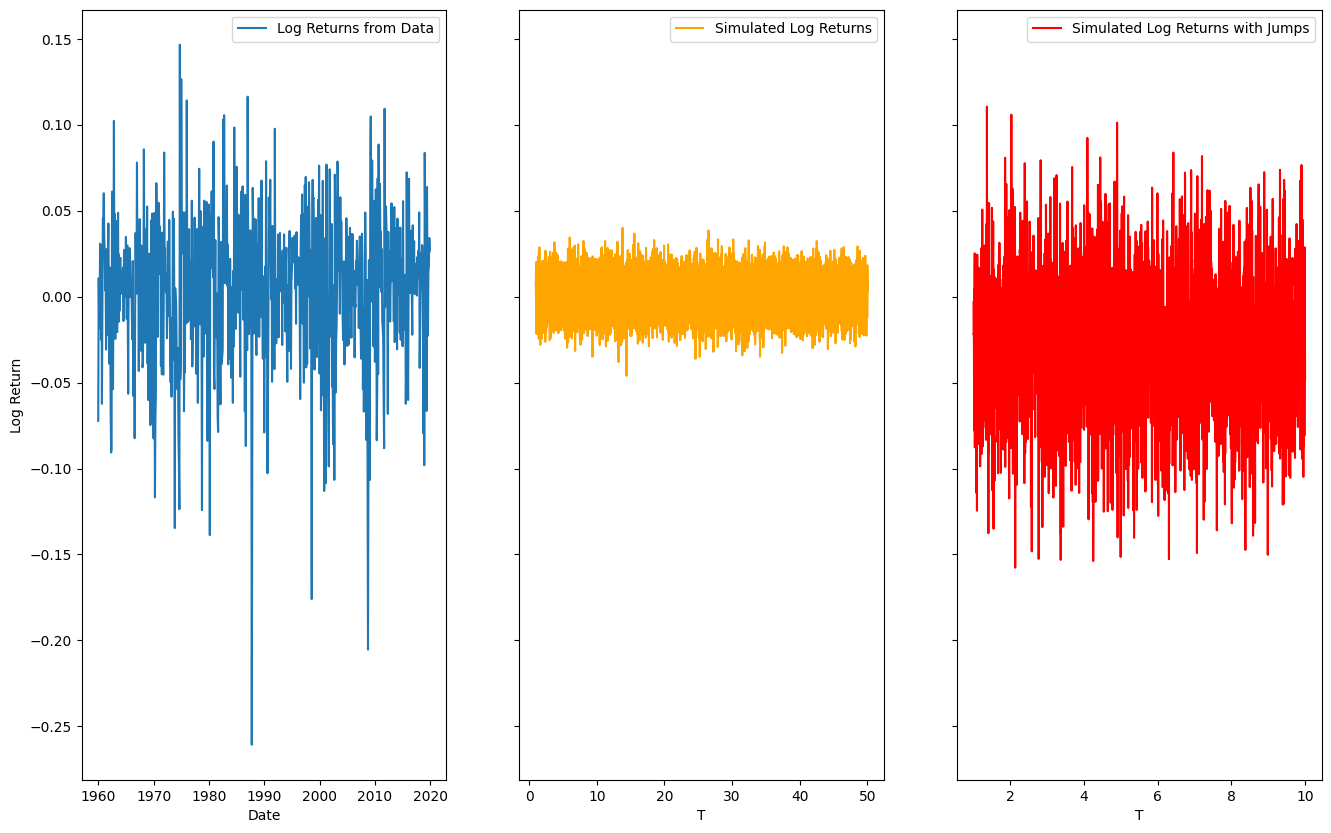

In [4]:
fig, axes = plt.subplots(1, 3, figsize=(16, 10), sharey=True)
sns.lineplot(data=real_returns, x='date', y='log_excess_ret', ax=axes[0], label='Log Returns from Data')
axes[0].set_xlabel('Date')
axes[0].set_ylabel('Log Return')
sns.lineplot(x=t, y=log_ret, label='Simulated Log Returns', ax=axes[1], color='orange')
axes[1].set_xlabel('T')
sns.lineplot(x=t2, y=jump_sim, label='Simulated Log Returns with Jumps', ax=axes[2], color='red')
axes[2].set_xlabel('T')
plt.show()

The basic log return model doesn't capture the full dynamics of the real world data. The real world data is much more volatile with periods of extreme volatility and plenty of outlier returns. The basic log return model is missing a jump component to model the crashes seen in the data.
Once we add in the jumps the model looks more like the data but still is not quite the same. We are missing a stochastic volatility component. The real world data exhibits volatility clustering that is not being captured by our Bernoulli-normal mixture model. In order to correct for this, we need our $\sigma$ component to vary through time. With properly estimated parameters, this would allow for the volatility clustering to be captured by our model. Furthermore, we can add in different kinds of jumps. There are some jumps that happen at known times, such as earnings releases, but there are also random jumps. By adding in two different jump components we could more accurately capture the timing of the jumps themselves. With stochastic volatility, pre-determined jumps, and random jumps we would have a much better model of returns. 

# Question 2
### 1

In [5]:
real_returns['rt+1'] = real_returns['log_excess_ret'].shift(1) * 12
real_returns.dropna(inplace=True)
X = real_returns['div_yld']
X = add_constant(X)
X.columns = ['alpha', 'dividend_yield']
y = real_returns['rt+1']

In [6]:
reg = OLS(y, X).fit(cov_type='HC3')
reg.summary()

<class 'statsmodels.iolib.summary.Summary'>
"""
                            OLS Regression Results                            
==============================================================================
Dep. Variable:                   rt+1   R-squared:                       0.010
Model:                            OLS   Adj. R-squared:                  0.008
Method:                 Least Squares   F-statistic:                     5.218
Date:                Sat, 14 Feb 2026   Prob (F-statistic):             0.0226
Time:                        15:48:09   Log-Likelihood:                -557.43
No. Observations:                 719   AIC:                             1119.
Df Residuals:                     717   BIC:                             1128.
Df Model:                           1                                         
Covariance Type:                  HC3                                         
==================================================================================
                     coef    std err          z      P>|z|      [0.025      0.975]
----------------------------------------------------------------------------------
alpha              0.1984      0.064      3.098      0.002       0.073       0.324
dividend_yield    -5.2511      2.299     -2.284      0.022      -9.757      -0.745
==============================================================================
Omnibus:                      108.222   Durbin-Watson:                   1.850
Prob(Omnibus):                  0.000   Jarque-Bera (JB):              304.555
Skew:                          -0.753   Prob(JB):                     7.36e-67
Kurtosis:                       5.810   Cond. No.                         101.
==============================================================================

Notes:
[1] Standard Errors are heteroscedasticity robust (HC3)
"""

In [7]:
print(reg.t_test('dividend_yield = 0'))

                             Test for Constraints                             
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
c0            -5.2511      2.299     -2.284      0.022      -9.757      -0.745


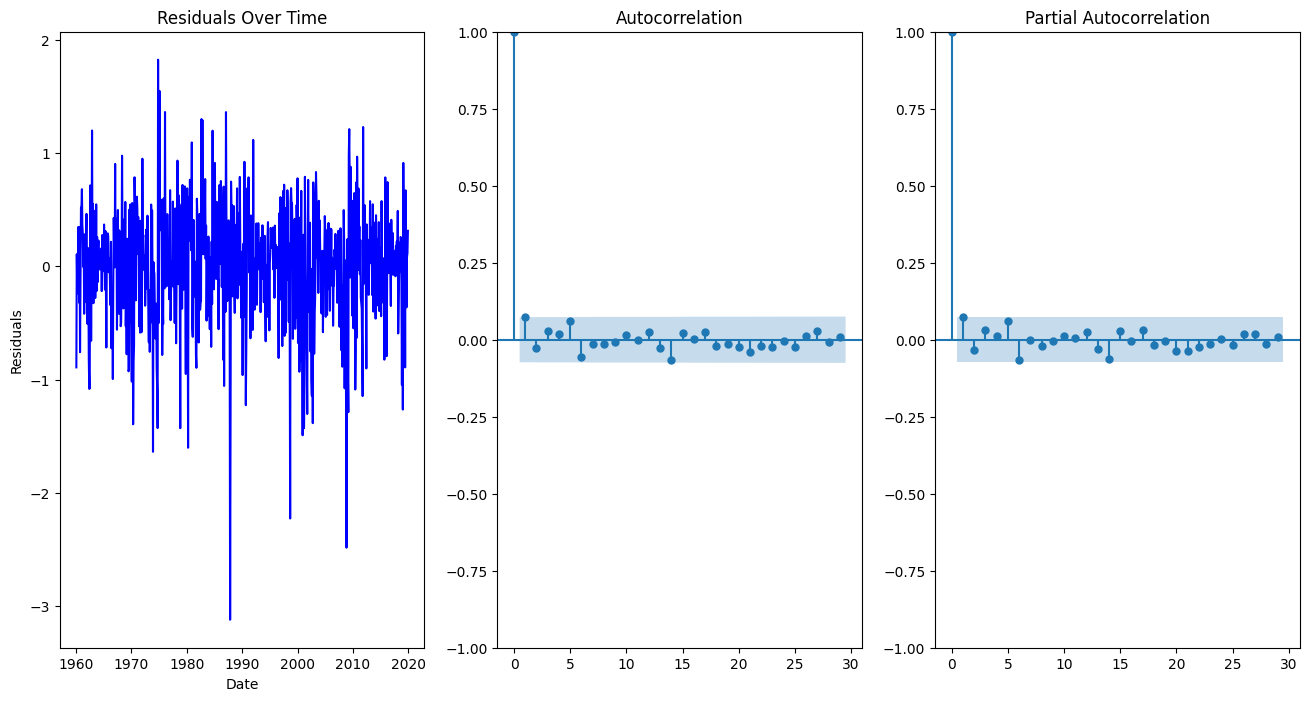

In [8]:
fig, axes = plt.subplots(1, 3, figsize=(16, 8))
sns.lineplot(x=real_returns['date'], y=reg.resid, ax=axes[0], color='blue')
axes[0].set_xlabel('Date')
axes[0].set_ylabel('Residuals')
axes[0].set_title('Residuals Over Time')
acf = plot_acf(x=reg.resid, ax=axes[1])
pacf = plot_pacf(x=reg.resid, ax=axes[2])
plt.show()

### 2

### 3

In [9]:
rtk_k = real_returns['log_excess_ret'].shift(1)
for i in range(2, 13):
    rtk_k += real_returns['log_excess_ret'].shift(i)

real_returns['rtk_k'] = rtk_k
real_returns.dropna(inplace=True)

In [10]:
X = add_constant(real_returns['div_yld'])
X.columns = ['alpha', 'dividend_yield']
y = real_returns['rtk_k']

In [11]:
overlap_reg = OLS(y, X).fit(cov_type='HAC', cov_kwds={'maxlags':1})
overlap_reg.summary()

<class 'statsmodels.iolib.summary.Summary'>
"""
                            OLS Regression Results                            
==============================================================================
Dep. Variable:                  rtk_k   R-squared:                       0.078
Model:                            OLS   Adj. R-squared:                  0.077
Method:                 Least Squares   F-statistic:                     24.90
Date:                Sat, 14 Feb 2026   Prob (F-statistic):           7.62e-07
Time:                        15:48:09   Log-Likelihood:                 314.85
No. Observations:                 707   AIC:                            -625.7
Df Residuals:                     705   BIC:                            -616.6
Df Model:                           1                                         
Covariance Type:                  HAC                                         
==================================================================================
                     coef    std err          z      P>|z|      [0.025      0.975]
----------------------------------------------------------------------------------
alpha              0.1778      0.026      6.955      0.000       0.128       0.228
dividend_yield    -4.5163      0.905     -4.990      0.000      -6.290      -2.742
==============================================================================
Omnibus:                       97.756   Durbin-Watson:                   0.156
Prob(Omnibus):                  0.000   Jarque-Bera (JB):              151.943
Skew:                          -0.916   Prob(JB):                     1.01e-33
Kurtosis:                       4.343   Cond. No.                         100.
==============================================================================

Notes:
[1] Standard Errors are heteroscedasticity and autocorrelation robust (HAC) using 1 lags and without small sample correction
"""

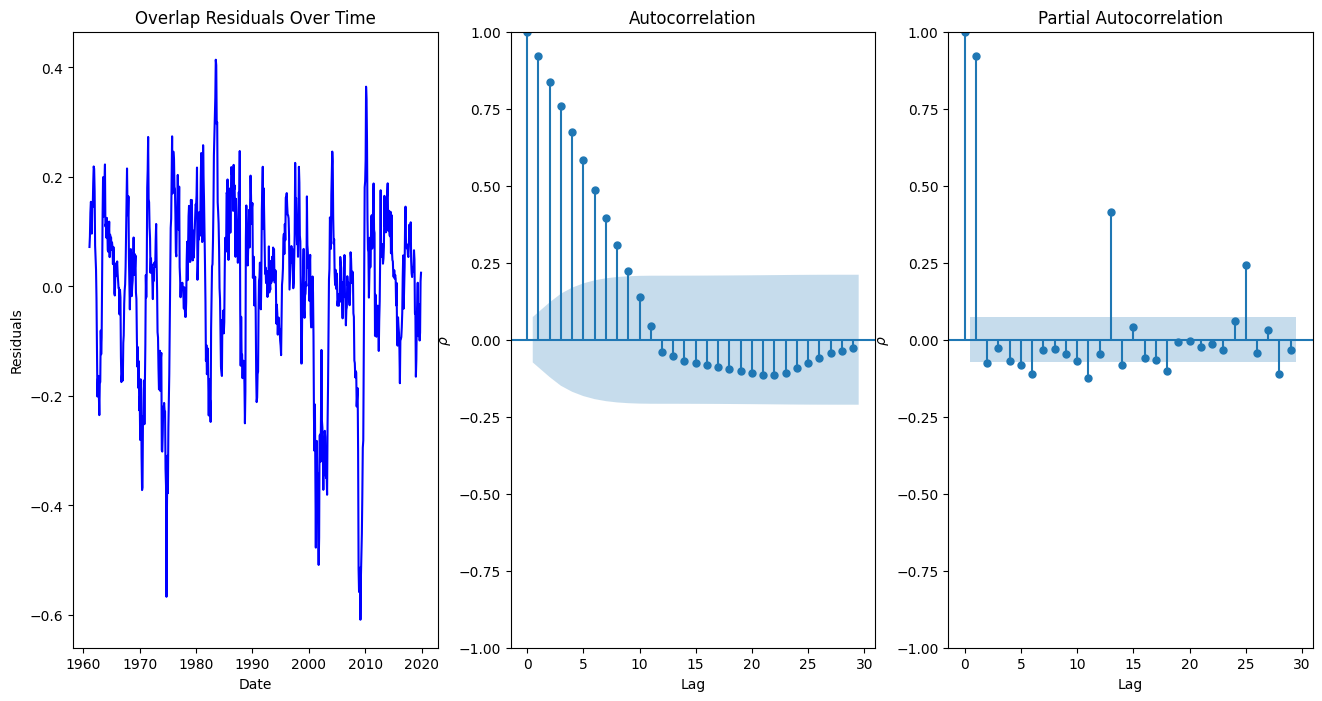

In [12]:
fig, axes = plt.subplots(1, 3, figsize=(16, 8))
sns.lineplot(x=real_returns['date'], y=overlap_reg.resid, ax=axes[0], color='blue')
axes[0].set_xlabel('Date')
axes[0].set_ylabel('Residuals')
axes[0].set_title('Overlap Residuals Over Time')
axes[1].set_xlabel('Lag')
axes[1].set_ylabel('$\\rho$')
axes[2].set_xlabel('Lag')
axes[2].set_ylabel('$\\rho$')
acf = plot_acf(x=overlap_reg.resid, ax=axes[1])
pacf = plot_pacf(x=overlap_reg.resid, ax=axes[2])
plt.show()

Looking at the residuals, PACF, and ACF it looks like the residuals follow an AR(1) process possible with a S-AR component at longer lags. We can confirm this by fitting an AR(1) and looking at the residuals of that to see if we can capture the dynamics of the process. The standard errors used here are the HAC errors, which correct for the autocorrelation and heteroskedasticity in the data.

In [13]:
print(overlap_reg.t_test('dividend_yield = 0'))
print(f'R-Squared: {0.078}')

                             Test for Constraints                             
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
c0            -4.5163      0.905     -4.990      0.000      -6.290      -2.742
R-Squared: 0.078


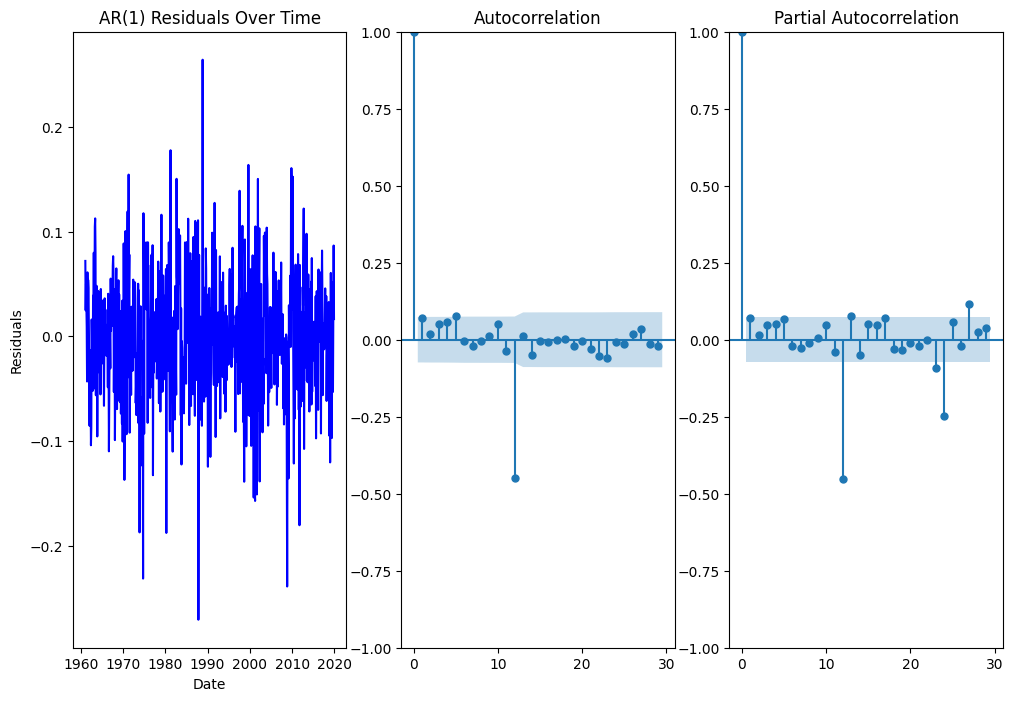

In [18]:
arima = ARIMA(overlap_reg.resid, order=(1, 0, 0), trend='n').fit(method='innovations_mle')
fig, axes = plt.subplots(1, 3, figsize=(12, 8))
sns.lineplot(x=real_returns['date'], y=arima.resid, ax=axes[0], color='blue')
axes[0].set_xlabel('Date')
axes[0].set_ylabel('Residuals')
axes[0].set_title('AR(1) Residuals Over Time')
acf = plot_acf(x=arima.resid, ax=axes[1])
pacf = plot_pacf(x=arima.resid, ax=axes[2])
plt.show()

In [19]:
arima.summary()

<class 'statsmodels.iolib.summary.Summary'>
"""
                               SARIMAX Results                                
==============================================================================
Dep. Variable:                      y   No. Observations:                  707
Model:                 ARIMA(1, 0, 0)   Log Likelihood                 984.700
Date:                Sat, 14 Feb 2026   AIC                          -1965.400
Time:                        15:52:36   BIC                          -1956.278
Sample:                             0   HQIC                         -1961.875
                                - 707                                         
Covariance Type:                  opg                                         
==============================================================================
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
ar.L1          0.9209      0.012     79.657      0.000       0.898       0.944
sigma2         0.0036      0.000     24.908      0.000       0.003       0.004
===================================================================================
Ljung-Box (L1) (Q):                   3.57   Jarque-Bera (JB):                74.23
Prob(Q):                              0.06   Prob(JB):                         0.00
Heteroskedasticity (H):               1.13   Skew:                            -0.24
Prob(H) (two-sided):                  0.35   Kurtosis:                         4.51
===================================================================================

Warnings:
[1] Covariance matrix calculated using the outer product of gradients (complex-step).
"""

With an AR(1) it looks like we can capture a lot of the dynamics of the series, leaving mostly white noise. There is still the seasonal component present in the PACF and ACF, but we won't address that here. 